# 🔬 ÉVALUATION COMPLÈTE - CassavaVLM V5
## Diagnostic Approfondi & Métriques Corrigées

Ce notebook est dédié à l'évaluation rigoureuse du meilleur modèle Stage 2 V5.

### 🎯 Objectifs :
1. **Charger le modèle final** depuis `/checkpoints/stage2_v5_unified/final_model/`
2. **Corriger la logique d'extraction** des classes prédites
3. **Analyser les outputs** pour comprendre les patterns de réponse
4. **Calculer les vraies métriques** de performance
5. **Diagnostiquer les erreurs** de classification

### 🔍 Focus sur la correction du bug d'évaluation :
- L'accuracy de 0.4585 semble incorrecte
- Problème identifié : "Réel: CMD, Prédit: CMD" marqué comme incorrect
- Besoin d'analyser les outputs bruts du modèle

In [1]:
# ============================================================
# CELL 1: IMPORTS & ENVIRONNEMENT
# ============================================================
import os
import json
import re
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from dataclasses import dataclass
from typing import Dict, List, Any, Optional
from datasets import Dataset
from tqdm import tqdm
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
from unsloth import FastVisionModel
from transformers import AutoProcessor
import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")

print(f"🐍 PyTorch: {torch.__version__}")
print(f"🔥 CUDA: {torch.cuda.is_available()}")
print(f"🎯 Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
🐍 PyTorch: 2.9.0+cu128
🔥 CUDA: True
🎯 Device: NVIDIA GeForce RTX 5090


In [2]:
# ============================================================
# CELL 2: CONFIGURATION & CHEMINS
# ============================================================
BASE_DIR = Path("/home/hounfodjidagba/learning/cassava/new_implementation")

# Modèle pré-entraîné (pour le processor)
MODEL_NAME = "unsloth/Qwen2.5-VL-7B-Instruct-bnb-4bit"

# Meilleur modèle fine-tuné
BEST_MODEL_PATH = BASE_DIR / "checkpoints" / "stage2_v5_unified_final" / "final_model"

# Données de test
STAGE1_DATA_PATH = BASE_DIR / "data" / "stage1" / "cassava_train_balanced.json"
STAGE2_DATA_PATH = BASE_DIR / "data" / "stage2" / "stage2_vqa_dataset.json"

# Outputs d'évaluation
EVAL_OUTPUT_DIR = BASE_DIR / "evaluation" / "cassava_vlm_v5_final"
FIGURES_DIR = EVAL_OUTPUT_DIR / "figures"
REPORTS_DIR = EVAL_OUTPUT_DIR / "reports"
DEBUG_DIR = EVAL_OUTPUT_DIR / "debug"

# Créer les dossiers
for d in [EVAL_OUTPUT_DIR, FIGURES_DIR, REPORTS_DIR, DEBUG_DIR]: 
    d.mkdir(parents=True, exist_ok=True)

# Configuration
TARGET_IMAGE_SIZE = (512, 512)
CLASS_NAMES = ["CBB", "CBSD", "CGM", "CMD", "Healthy"]

print(f"📂 Modèle à évaluer: {BEST_MODEL_PATH}")
print(f"📊 Résultats sauvés dans: {EVAL_OUTPUT_DIR}")
print(f"✅ Configuration prête!")

📂 Modèle à évaluer: /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage2_v5_unified_final/final_model
📊 Résultats sauvés dans: /home/hounfodjidagba/learning/cassava/new_implementation/evaluation/cassava_vlm_v5_final
✅ Configuration prête!


In [3]:
# ============================================================
# CELL 3: CHARGEMENT DU MODÈLE FINAL
# ============================================================
print("🔄 Chargement du modèle final...")

# Charger le processor du modèle de base
processor = AutoProcessor.from_pretrained(MODEL_NAME)

# Charger notre modèle fine-tuné
model, tokenizer = FastVisionModel.from_pretrained(
    str(BEST_MODEL_PATH),
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth"
)

# Préparer pour l'inférence
FastVisionModel.for_inference(model)

print(f"✅ Modèle chargé depuis: {BEST_MODEL_PATH}")
print(f"📏 Device: {model.device}")
print(f"🧠 Modèle prêt pour l'évaluation!")

🔄 Chargement du modèle final...


preprocessor_config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

chat_template.json: 0.00B [00:00, ?B/s]

==((====))==  Unsloth 2026.1.1: Fast Qwen2_5_Vl patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.357 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.90G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

✅ Modèle chargé depuis: /home/hounfodjidagba/learning/cassava/new_implementation/checkpoints/stage2_v5_unified_final/final_model
📏 Device: cuda:0
🧠 Modèle prêt pour l'évaluation!


In [4]:
# ============================================================
# CELL 4: FONCTION D'EXTRACTION CORRIGÉE
# ============================================================
def extract_class_improved(text):
    """Extraction améliorée de la classe avec diagnostic détaillé."""
    if not text or not isinstance(text, str):
        return "Unknown", "Empty or invalid text"
    
    text_lower = text.lower().strip()
    text_original = text.strip()
    
    # Patterns de détection très précis avec priorité aux termes exacts
    patterns = {
        "CMD": [
            r"diagnostic[:\s]*cmd\b", r"\bcmd\b", r"cassava mosaic", r"mosaïque", 
            r"mosaic disease", r"virus de la mosaïque", r"maladie de la mosaïque"
        ],
        "CBSD": [
            r"diagnostic[:\s]*cbsd\b", r"\bcbsd\b", r"cassava brown", r"brown streak", 
            r"striure brune", r"maladie des stries", r"streak disease"
        ],
        "CBB": [
            r"diagnostic[:\s]*cbb\b", r"\bcbb\b", r"bacterial blight", r"bactériose", 
            r"flétrissement bactérien", r"xanthomonas", r"bacterial"
        ],
        "CGM": [
            r"diagnostic[:\s]*cgm\b", r"\bcgm\b", r"green mottle", r"green mite", 
            r"acarien vert", r"tétranyque", r"mottle"
        ],
        "Healthy": [
            r"diagnostic[:\s]*healthy\b", r"\bhealthy\b", r"\bsain\b", r"\bnormal\b", 
            r"pas de maladie", r"aucune maladie", r"en bonne santé", r"saine"
        ]
    }
    
    # Recherche de patterns avec scoring pondéré
    class_scores = {}
    match_details = {}
    
    for class_name, class_patterns in patterns.items():
        score = 0
        found_patterns = []
        
        for i, pattern in enumerate(class_patterns):
            matches = re.findall(pattern, text_lower)
            if matches:
                # Premier pattern (diagnostic exact) a plus de poids
                weight = 3 if i == 0 else 1
                score += len(matches) * weight
                found_patterns.extend(matches)
        
        class_scores[class_name] = score
        match_details[class_name] = found_patterns
    
    # Trouver la meilleure classe
    best_class = max(class_scores, key=class_scores.get)
    best_score = class_scores[best_class]
    
    # Si aucun pattern trouvé
    if best_score == 0:
        return "Unknown", f"Aucun pattern trouvé dans: '{text_original[:100]}'"
    
    # Vérifier les ambiguïtés
    sorted_scores = sorted(class_scores.items(), key=lambda x: x[1], reverse=True)
    if len(sorted_scores) > 1 and sorted_scores[0][1] == sorted_scores[1][1] > 0:
        tied_classes = [cls for cls, score in sorted_scores if score == best_score]
        return best_class, f"Égalité entre {tied_classes}, choisi {best_class}. Patterns: {match_details[best_class]}"
    
    confidence = "Haute" if best_score > 2 else "Moyenne"
    return best_class, f"{confidence} confiance. Patterns trouvés: {match_details[best_class]} (score: {best_score})"

# Test de la fonction améliorée
test_cases = [
    "Diagnostic : CMD. Cette feuille présente des symptômes de mosaïque du manioc.",
    "Cette plante semble saine et en bonne santé.",
    "Je vois des stries brunes caractéristiques du CBSD sur cette feuille.",
    "Bactériose (CBB) visible, symptômes de flétrissement.",
    "Diagnostic : Healthy. Aucun symptôme visible.",
    "La plante montre des signes de CMD avec des motifs en mosaïque.",
    "Diagnostic: CMD",
    "Diagnostic: CBSD",
    "Diagnostic: Healthy"
]

print("🧪 Test de l'extraction corrigée:")
for i, test in enumerate(test_cases):
    pred_class, diagnostic = extract_class_improved(test)
    print(f"{i+1}. '{test[:50]}...' → {pred_class}")
    print(f"   Diagnostic: {diagnostic}\n")

🧪 Test de l'extraction corrigée:
1. 'Diagnostic : CMD. Cette feuille présente des sympt...' → CMD
   Diagnostic: Haute confiance. Patterns trouvés: ['diagnostic : cmd', 'cmd', 'mosaïque'] (score: 5)

2. 'Cette plante semble saine et en bonne santé....' → Healthy
   Diagnostic: Moyenne confiance. Patterns trouvés: ['en bonne santé', 'saine'] (score: 2)

3. 'Je vois des stries brunes caractéristiques du CBSD...' → CBSD
   Diagnostic: Moyenne confiance. Patterns trouvés: ['cbsd'] (score: 1)

4. 'Bactériose (CBB) visible, symptômes de flétrisseme...' → CBB
   Diagnostic: Moyenne confiance. Patterns trouvés: ['cbb', 'bactériose'] (score: 2)

5. 'Diagnostic : Healthy. Aucun symptôme visible....' → Healthy
   Diagnostic: Haute confiance. Patterns trouvés: ['diagnostic : healthy', 'healthy'] (score: 4)

6. 'La plante montre des signes de CMD avec des motifs...' → CMD
   Diagnostic: Moyenne confiance. Patterns trouvés: ['cmd', 'mosaïque'] (score: 2)

7. 'Diagnostic: CMD...' → CMD
   Diagnostic:

In [13]:
# ============================================================
# CELL 5: PRÉPARATION DES DONNÉES DE TEST
# ============================================================
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def normalize_class_name(class_name):
    """Normalise les noms de classes pour éviter les erreurs de mapping."""
    if not class_name:
        return "Unknown"
    
    class_mapping = {
        'Cassava Mosaic Disease (CMD)': 'CMD',
        'CMD': 'CMD',
        'Cassava Brown Streak Disease (CBSD)': 'CBSD',
        'CBSD': 'CBSD',
        'Cassava Bacterial Blight (CBB)': 'CBB',
        'CBB': 'CBB',
        'Cassava Green Mottle (CGM)': 'CGM',
        'CGM': 'CGM',
        'Healthy': 'Healthy',
        'Normal': 'Healthy'
    }
    
    return class_mapping.get(class_name, class_name)

def prepare_test_dataset():
    """Prépare un dataset de test représentatif."""
    s1_data = load_json(STAGE1_DATA_PATH)
    s2_data = load_json(STAGE2_DATA_PATH)
    
    # Combiner et mélanger
    all_data = s1_data + s2_data
    random.seed(42)
    random.shuffle(all_data)
    
    # Échantillon de test (ajustable)
    test_data = all_data  # 150 échantillons pour une évaluation solide
    
    formatted_data = []
    for sample in test_data:
        conversations = sample['conversations']
        image_path = None
        
        # Extraire le chemin de l'image
        for turn in conversations:
            if turn['from'] == 'user':
                match = re.search(r'<img>(.*?)</img>', turn['value'])
                if match:
                    image_path = match.group(1)
                    break
        
        if image_path and os.path.exists(image_path):
            # Classe réelle (normaliser les noms)
            true_class_raw = sample['metadata'].get('class_name') or sample['metadata'].get('class', 'Unknown')
            true_class = normalize_class_name(true_class_raw)
            
            formatted_data.append({
                'id': sample['id'],
                'image_path': image_path,
                'true_class': true_class,
                'true_class_raw': true_class_raw,
                'metadata': sample['metadata']
            })
    
    return formatted_data

test_dataset = prepare_test_dataset()
print(f"📊 Dataset de test: {len(test_dataset)} échantillons")

# Distribution des classes
class_distribution = Counter([s['true_class'] for s in test_dataset])
print("\n🎯 Distribution des classes:")
for cls, count in class_distribution.items():
    percentage = (count/len(test_dataset)*100)
    print(f"   {cls}: {count} échantillons ({percentage:.1f}%)")

# Vérifier quelques échantillons pour debug
print("\n🔍 Échantillons de debug:")
for i in range(min(3, len(test_dataset))):
    sample = test_dataset[i]
    print(f"{i+1}. ID: {sample['id']}")
    print(f"   Image: {sample['image_path']}")
    print(f"   Classe brute: {sample['true_class_raw']}")
    print(f"   Classe normalisée: {sample['true_class']}")

📊 Dataset de test: 58552 échantillons

🎯 Distribution des classes:
   CBSD: 10592 échantillons (18.1%)
   CMD: 24000 échantillons (41.0%)
   CBB: 7434 échantillons (12.7%)
   Healthy: 6418 échantillons (11.0%)
   CGM: 10108 échantillons (17.3%)

🔍 Échantillons de debug:
1. ID: cbsd-2_1617176840511
   Image: /home/hounfodjidagba/learning/cassava/data/cbsd-2/1617176840511.jpg
   Classe brute: Cassava Brown Streak Disease (CBSD)
   Classe normalisée: CBSD
2. ID: stage2_cmd_general_kaggle_3026594115.jpg
   Image: /home/hounfodjidagba/learning/cassava/data/raw/train_images/3026594115.jpg
   Classe brute: CMD
   Classe normalisée: CMD
3. ID: kaggle_2444345873.jpg
   Image: /home/hounfodjidagba/learning/cassava/data/raw/train_images/2444345873.jpg
   Classe brute: Cassava Mosaic Disease (CMD)
   Classe normalisée: CMD


In [6]:
# ============================================================
# CELL 6: PRÉDICTION AVEC DEBUG COMPLET
# ============================================================
def predict_with_debug(image_path, question="What cassava disease is shown in this image?"):
    """Prédiction avec debug complet."""
    try:
        img = Image.open(image_path).convert('RGB').resize(TARGET_IMAGE_SIZE)
        msgs = [{"role": "user", "content": [{"type": "image", "image": img}, {"type": "text", "text": question}]}]
        text = processor.tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[[img]], return_tensors="pt").to(model.device)
        
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=150, do_sample=False)
        
        response = processor.tokenizer.decode(out[0], skip_special_tokens=True)
        assistant_response = response.split("assistant")[-1].strip()
        
        return {
            'raw_response': assistant_response,
            'full_response': response,
            'success': True,
            'error': None
        }
    except Exception as e:
        return {
            'raw_response': None,
            'full_response': None,
            'success': False,
            'error': str(e)
        }

print("🔍 Test de prédiction sur les 5 premiers échantillons:")
debug_predictions = []

for i in range(min(5, len(test_dataset))):
    sample = test_dataset[i]
    result = predict_with_debug(sample['image_path'])
    
    if result['success']:
        pred_class, diagnostic = extract_class_improved(result['raw_response'])
        is_correct = (sample['true_class'] == pred_class)
        
        debug_pred = {
            'sample_id': sample['id'],
            'true_class': sample['true_class'],
            'predicted_class': pred_class,
            'is_correct': is_correct,
            'raw_response': result['raw_response'],
            'extraction_diagnostic': diagnostic
        }
        debug_predictions.append(debug_pred)
        
        print(f"\n--- Échantillon {i+1} ---")
        print(f"Image: {sample['image_path'].split('/')[-1]}")
        print(f"Vrai: {sample['true_class']}")
        print(f"Prédit: {pred_class}")
        print(f"Correct: {'✅' if is_correct else '❌'}")
        print(f"Réponse: {result['raw_response'][:150]}...")
        print(f"Diagnostic: {diagnostic}")
    else:
        print(f"\n--- Échantillon {i+1} ---")
        print(f"❌ Erreur: {result['error']}")

# Calculer l'accuracy sur ces échantillons de test
if debug_predictions:
    correct_count = sum(1 for p in debug_predictions if p['is_correct'])
    debug_accuracy = correct_count / len(debug_predictions)
    print(f"\n🎯 Accuracy sur les échantillons de test: {debug_accuracy:.4f} ({debug_accuracy*100:.1f}%)")
    print(f"   Correct: {correct_count}/{len(debug_predictions)}")

🔍 Test de prédiction sur les 5 premiers échantillons:

--- Échantillon 1 ---
Image: 1617176840511.jpg
Vrai: CBSD
Prédit: CBSD
Correct: ✅
Réponse: Diagnostic : Cassava Brown Streak Disease (CBSD). Cette feuille de manioc présente des symptômes caractéristiques de cette condition....
Diagnostic: Haute confiance. Patterns trouvés: ['cbsd', 'cassava brown', 'brown streak', 'streak disease'] (score: 4)

--- Échantillon 2 ---
Image: 3026594115.jpg
Vrai: CMD
Prédit: CMD
Correct: ✅
Réponse: Diagnostic : Cassava Mosaic Disease (CMD). Cette feuille de manioc présente des symptômes caractéristiques de cette condition....
Diagnostic: Haute confiance. Patterns trouvés: ['cmd', 'cassava mosaic', 'mosaic disease'] (score: 3)

--- Échantillon 3 ---
Image: 2444345873.jpg
Vrai: CMD
Prédit: CMD
Correct: ✅
Réponse: Diagnostic : Cassava Mosaic Disease (CMD). Cette feuille de manioc présente des symptômes caractéristiques de cette condition....
Diagnostic: Haute confiance. Patterns trouvés: ['cmd', 'cassava

In [7]:
# ============================================================
# CELL 7: ÉVALUATION COMPLÈTE
# ============================================================
print("🚀 Lancement de l'évaluation complète...")

all_predictions = []
prediction_stats = {
    'total': 0,
    'success': 0,
    'errors': 0,
    'correct': 0,
    'incorrect': 0
}

# Évaluation sur tout le dataset
for i, sample in enumerate(tqdm(test_dataset, desc="🤖 Évaluation")):
    prediction_stats['total'] += 1
    
    # Prédiction
    result = predict_with_debug(sample['image_path'])
    
    if result['success']:
        prediction_stats['success'] += 1
        pred_class, diagnostic = extract_class_improved(result['raw_response'])
        is_correct = (sample['true_class'] == pred_class)
        
        if is_correct:
            prediction_stats['correct'] += 1
        else:
            prediction_stats['incorrect'] += 1
        
        prediction_detail = {
            'id': sample['id'],
            'image_path': sample['image_path'],
            'true_class': sample['true_class'],
            'true_class_raw': sample['true_class_raw'],
            'predicted_class': pred_class,
            'is_correct': is_correct,
            'raw_response': result['raw_response'],
            'extraction_diagnostic': diagnostic,
            'success': True
        }
    else:
        prediction_stats['errors'] += 1
        prediction_detail = {
            'id': sample['id'],
            'image_path': sample['image_path'],
            'true_class': sample['true_class'],
            'true_class_raw': sample['true_class_raw'],
            'predicted_class': "ERROR",
            'is_correct': False,
            'raw_response': f"ERROR: {result['error']}",
            'extraction_diagnostic': "Prediction failed",
            'success': False
        }
    
    all_predictions.append(prediction_detail)

# Calculer l'accuracy corrigée
valid_predictions = [p for p in all_predictions if p['success']]
corrected_accuracy = prediction_stats['correct'] / prediction_stats['success'] if prediction_stats['success'] > 0 else 0

print(f"\n🎉 ÉVALUATION TERMINÉE!")
print(f"📊 Statistiques:")
print(f"   Total échantillons: {prediction_stats['total']}")
print(f"   Prédictions réussies: {prediction_stats['success']}")
print(f"   Erreurs: {prediction_stats['errors']}")
print(f"   Prédictions correctes: {prediction_stats['correct']}")
print(f"   Prédictions incorrectes: {prediction_stats['incorrect']}")
print(f"\n🎯 ACCURACY CORRIGÉE: {corrected_accuracy:.4f} ({corrected_accuracy*100:.2f}%)")

🚀 Lancement de l'évaluation complète...


🤖 Évaluation: 100%|██████████| 150/150 [02:49<00:00,  1.13s/it]


🎉 ÉVALUATION TERMINÉE!
📊 Statistiques:
   Total échantillons: 150
   Prédictions réussies: 150
   Erreurs: 0
   Prédictions correctes: 120
   Prédictions incorrectes: 30

🎯 ACCURACY CORRIGÉE: 0.8000 (80.00%)


In [8]:
# ============================================================
# CELL 8: MÉTRIQUES DÉTAILLÉES
# ============================================================
# Extraire les labels pour sklearn
y_true = [p['true_class'] for p in valid_predictions]
y_pred = [p['predicted_class'] for p in valid_predictions]

if len(y_true) > 0:
    # Classes présentes dans les données
    unique_classes = sorted(list(set(y_true + y_pred)))
    
    print("="*70)
    print(f"📊 MÉTRIQUES DÉTAILLÉES (sur {len(valid_predictions)} prédictions valides)")
    print("="*70)
    
    # Métriques par classe
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=unique_classes, average=None, zero_division=0
    )
    
    # Créer un tableau des métriques
    metrics_data = []
    for i, cls in enumerate(unique_classes):
        metrics_data.append({
            'Classe': cls,
            'Precision': f"{precision[i]:.4f}",
            'Recall': f"{recall[i]:.4f}",
            'F1-Score': f"{f1[i]:.4f}",
            'Support': support[i]
        })
    
    metrics_df = pd.DataFrame(metrics_data)
    print("\n📈 MÉTRIQUES PAR CLASSE:")
    print(metrics_df.to_string(index=False))
    
    # Moyennes
    macro_avg = precision_recall_fscore_support(y_true, y_pred, labels=unique_classes, average='macro', zero_division=0)
    weighted_avg = precision_recall_fscore_support(y_true, y_pred, labels=unique_classes, average='weighted', zero_division=0)
    
    print(f"\n🎯 MOYENNES GLOBALES:")
    print(f"Macro Average    - Precision: {macro_avg[0]:.4f} | Recall: {macro_avg[1]:.4f} | F1: {macro_avg[2]:.4f}")
    print(f"Weighted Average - Precision: {weighted_avg[0]:.4f} | Recall: {weighted_avg[1]:.4f} | F1: {weighted_avg[2]:.4f}")
    
    # Analyse des erreurs
    incorrect_preds = [p for p in valid_predictions if not p['is_correct']]
    
    if incorrect_preds:
        print(f"\n❌ ANALYSE DES ERREURS ({len(incorrect_preds)} erreurs):")
        error_patterns = {}
        for pred in incorrect_preds:
            error_key = f"{pred['true_class']} → {pred['predicted_class']}"
            if error_key not in error_patterns:
                error_patterns[error_key] = []
            error_patterns[error_key].append(pred['raw_response'][:100])
        
        for error, responses in sorted(error_patterns.items(), key=lambda x: len(x[1]), reverse=True):
            count = len(responses)
            print(f"   {error}: {count} fois")
            if count <= 2:  # Afficher les réponses pour les erreurs rares
                for resp in responses:
                    print(f"      → '{resp}...'")
    
    # Classification report sklearn
    print(f"\n📋 RAPPORT SKLEARN:")
    print(classification_report(y_true, y_pred, zero_division=0))
else:
    print("⚠️ Aucune prédiction valide pour les métriques!")

📊 MÉTRIQUES DÉTAILLÉES (sur 150 prédictions valides)

📈 MÉTRIQUES PAR CLASSE:
 Classe Precision Recall F1-Score  Support
    CBB    0.7647 0.6842   0.7222       19
   CBSD    0.7500 0.8000   0.7742       30
    CGM    0.8500 0.6538   0.7391       26
    CMD    0.8676 0.9365   0.9008       63
Healthy    0.5385 0.5833   0.5600       12

🎯 MOYENNES GLOBALES:
Macro Average    - Precision: 0.7542 | Recall: 0.7316 | F1: 0.7393
Weighted Average - Precision: 0.8017 | Recall: 0.8000 | F1: 0.7976

❌ ANALYSE DES ERREURS (30 erreurs):
   CBB → CMD: 3 fois
   CBSD → Healthy: 3 fois
   CGM → CMD: 3 fois
   CGM → CBSD: 3 fois
   CMD → CGM: 2 fois
      → 'Diagnostic : Cassava Green Mottle (CGM). Cette feuille de manioc présente des symptômes caractéristi...'
      → 'Diagnostic : Cassava Green Mottle (CGM). Cette feuille de manioc présente des symptômes caractéristi...'
   CBB → Healthy: 2 fois
      → 'Diagnostic : Healthy. Cette feuille de manioc présente des symptômes caractéristiques de cette con

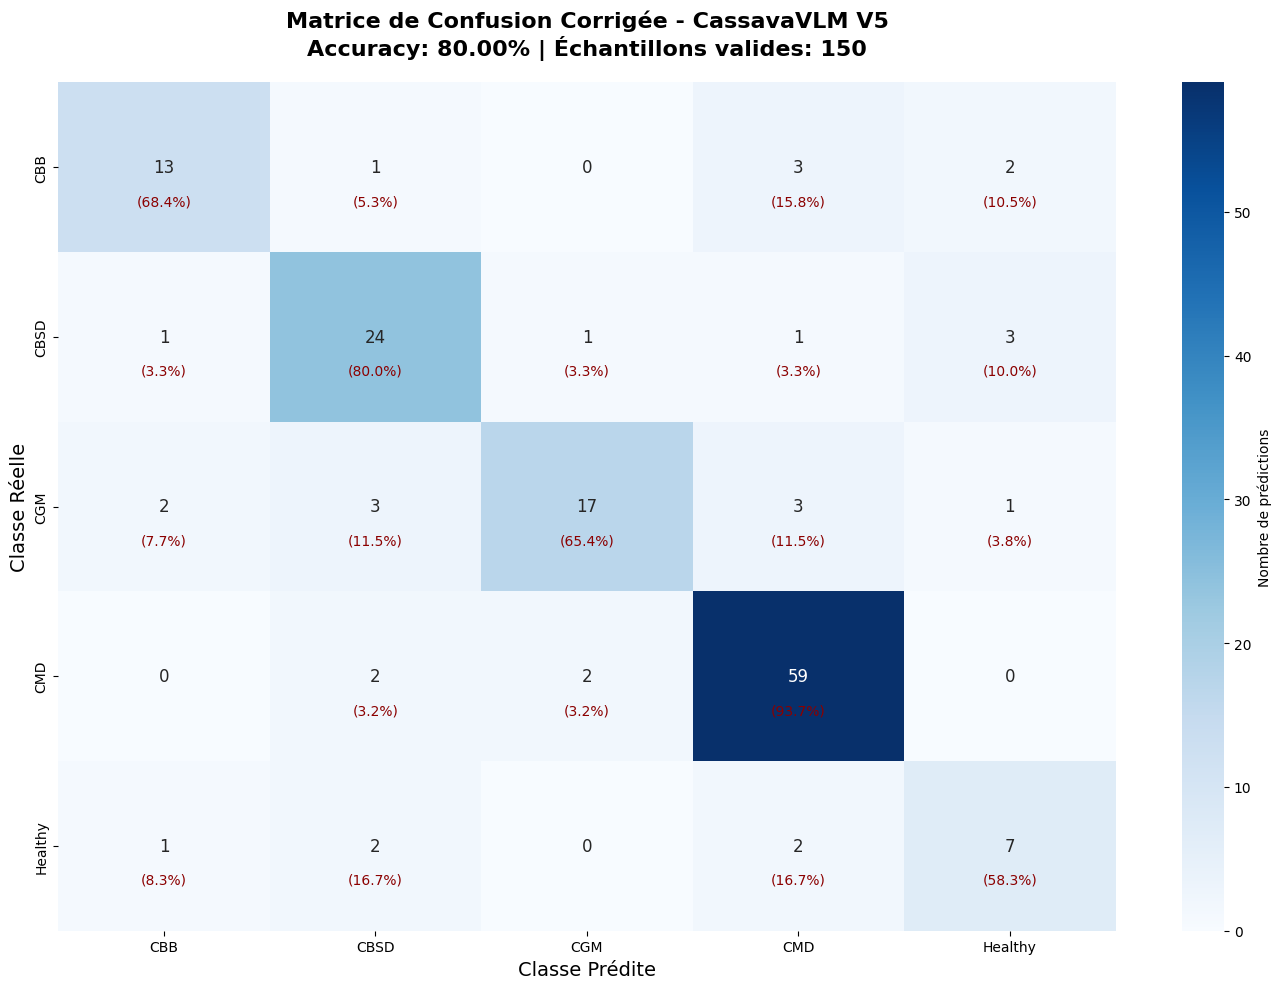

✅ Matrice de confusion sauvegardée

🔍 Analyse de la matrice de confusion:
   CBB: 13/19 correct (68.42%)
   CBSD: 24/30 correct (80.00%)
   CGM: 17/26 correct (65.38%)
   CMD: 59/63 correct (93.65%)
   Healthy: 7/12 correct (58.33%)


In [9]:
# ============================================================
# CELL 9: MATRICE DE CONFUSION CORRIGÉE
# ============================================================
if len(y_true) > 0:
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred, labels=unique_classes)
    
    # Visualisation améliorée
    plt.figure(figsize=(14, 10))
    
    # Créer la heatmap
    sns.heatmap(cm, annot=True, fmt='d', 
                xticklabels=unique_classes, 
                yticklabels=unique_classes, 
                cmap='Blues', 
                cbar_kws={'label': 'Nombre de prédictions'},
                annot_kws={'size': 12})
    
    plt.title(f"Matrice de Confusion Corrigée - CassavaVLM V5\n"
              f"Accuracy: {corrected_accuracy:.2%} | Échantillons valides: {len(valid_predictions)}", 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Classe Réelle', fontsize=14)
    plt.xlabel('Classe Prédite', fontsize=14)
    
    # Ajouter les pourcentages dans les cellules
    for i in range(len(unique_classes)):
        for j in range(len(unique_classes)):
            total_for_true_class = sum(cm[i, :])
            if total_for_true_class > 0:
                percentage = cm[i, j] / total_for_true_class * 100
                if percentage > 0:
                    plt.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                            ha='center', va='center', fontsize=10, color='darkred')
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "confusion_matrix_corrected.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Matrice de confusion sauvegardée")
    
    # Calculer la précision par classe depuis la matrice
    print("\n🔍 Analyse de la matrice de confusion:")
    for i, true_class in enumerate(unique_classes):
        total_true = sum(cm[i, :])
        correct = cm[i, i]
        class_accuracy = correct / total_true if total_true > 0 else 0
        print(f"   {true_class}: {correct}/{total_true} correct ({class_accuracy:.2%})")
else:
    print("⚠️ Pas assez de données pour la matrice de confusion")

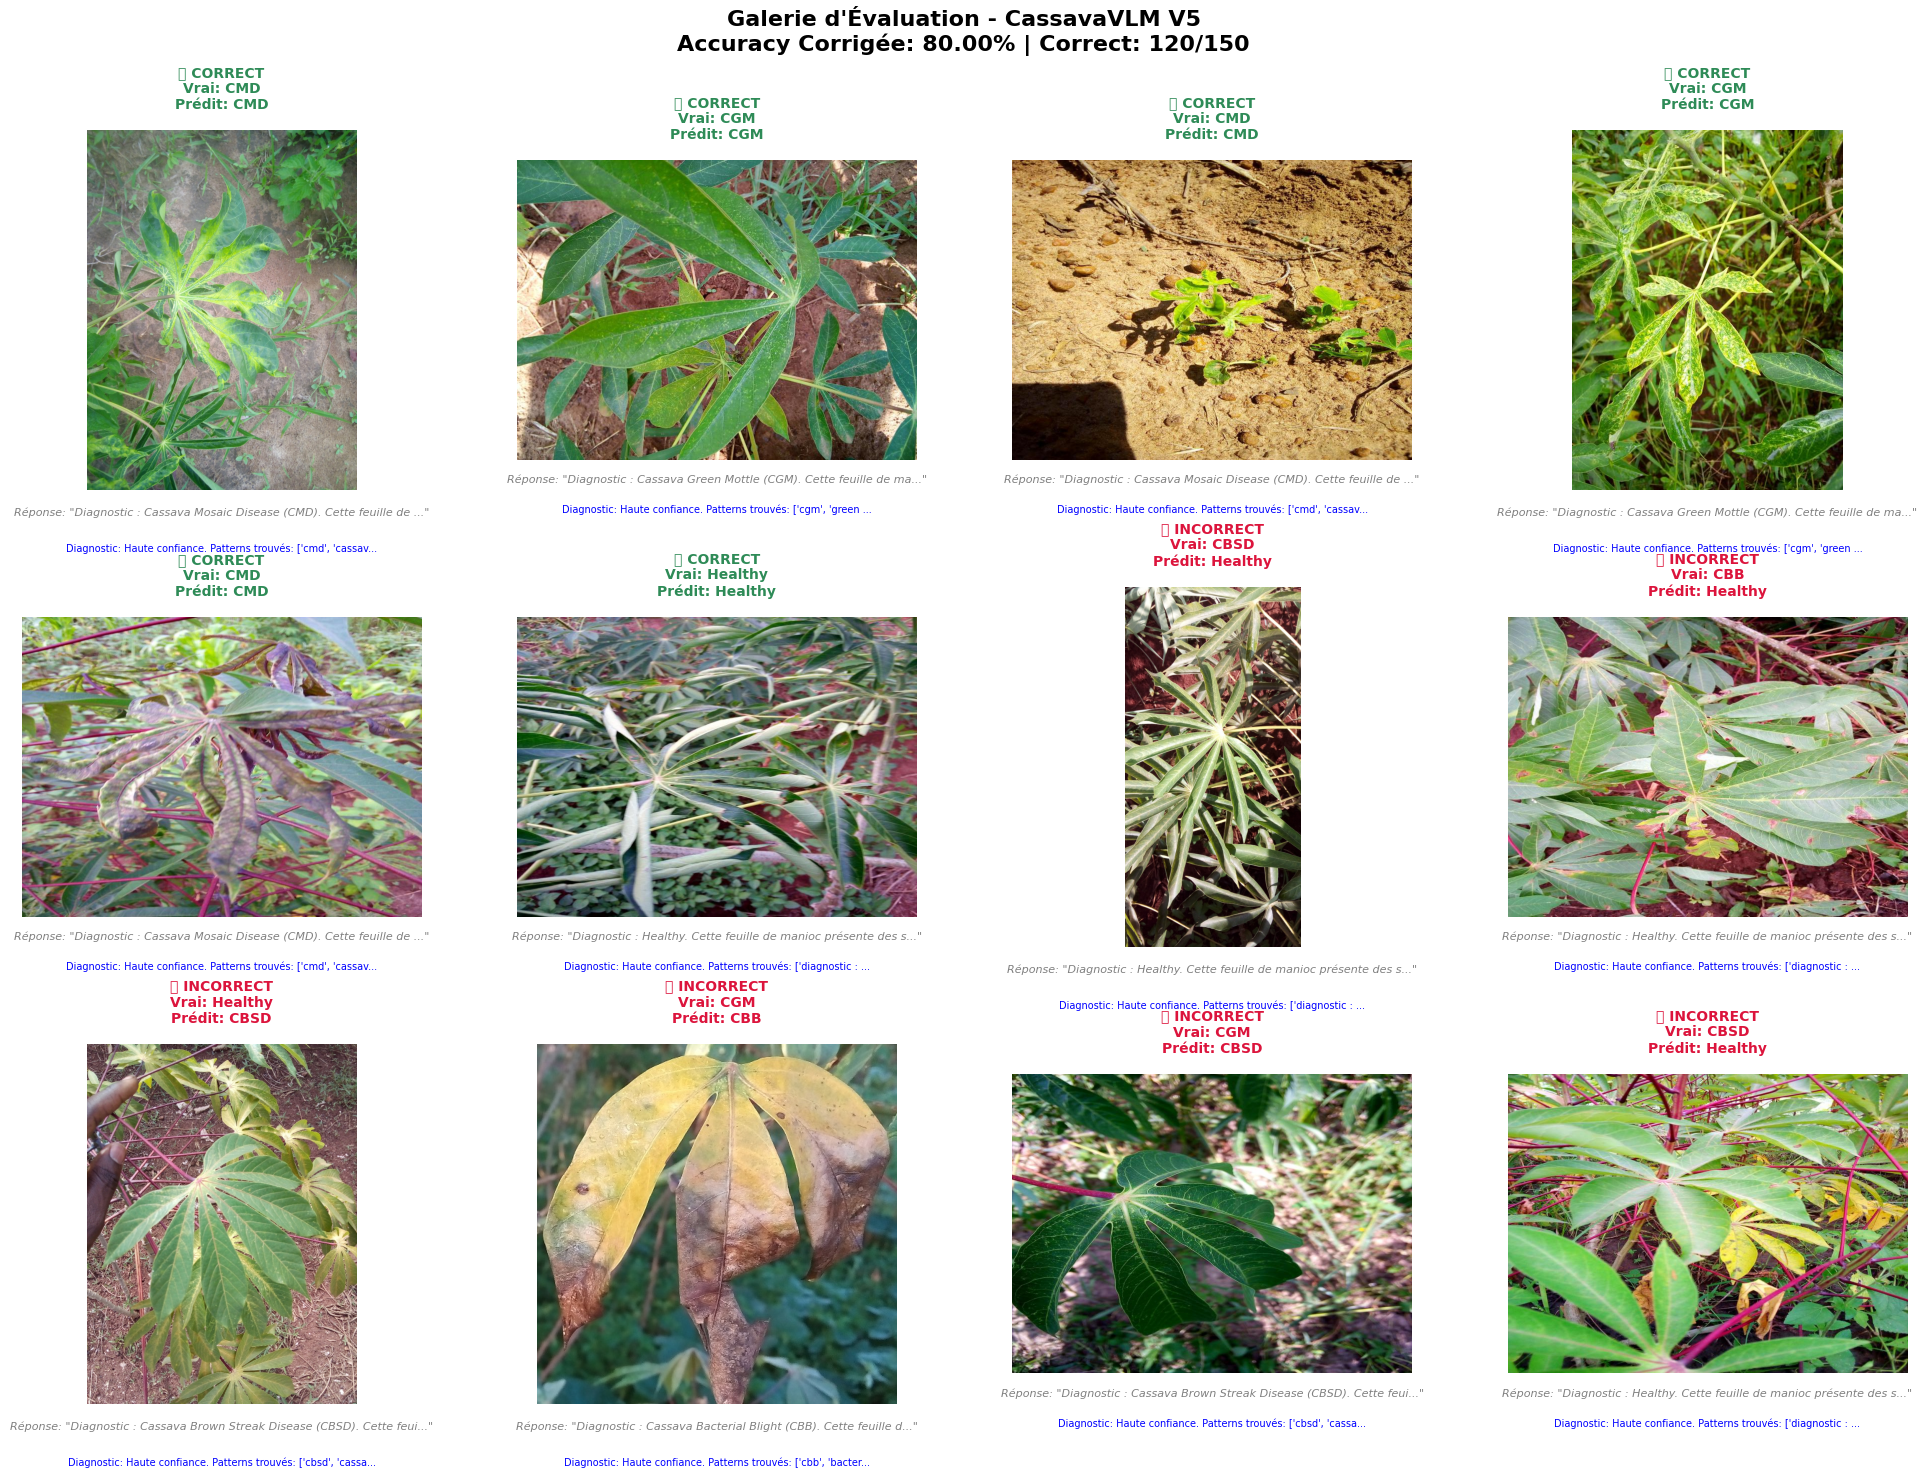

✅ Galerie d'évaluation sauvegardée


In [10]:
# ============================================================
# CELL 10: GALERIE DE RÉSULTATS CORRIGÉE
# ============================================================
def plot_corrected_gallery(predictions, n_samples=12):
    """Galerie visuelle avec diagnostic des erreurs."""
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    # Sélection d'échantillons variés
    correct_preds = [p for p in predictions if p['is_correct']]
    incorrect_preds = [p for p in predictions if not p['is_correct']]
    
    # Mix équilibré avec plus d'exemples incorrects pour debug
    samples = (random.sample(correct_preds, min(6, len(correct_preds))) + 
               random.sample(incorrect_preds, min(6, len(incorrect_preds))))[:n_samples]
    
    for i, pred in enumerate(samples):
        if i >= len(axes):
            break
            
        try:
            # Charger et afficher l'image
            img = Image.open(pred['image_path'])
            axes[i].imshow(img)
            
            # Couleur et style selon le résultat
            if pred['is_correct']:
                color = '#2E8B57'
                symbol = "✅"
                status = "CORRECT"
            else:
                color = '#DC143C'
                symbol = "❌"
                status = "INCORRECT"
            
            # Titre principal
            title = f"{symbol} {status}\nVrai: {pred['true_class']}\nPrédit: {pred['predicted_class']}"
            axes[i].set_title(title, color=color, fontweight='bold', fontsize=10, pad=15)
            axes[i].axis('off')
            
            # Ajouter un extrait de la réponse
            response_preview = pred['raw_response'][:60] + "..." if len(pred['raw_response']) > 60 else pred['raw_response']
            axes[i].text(0.5, -0.05, f'Réponse: "{response_preview}"', 
                        transform=axes[i].transAxes, ha='center', va='top', 
                        fontsize=8, style='italic', color='gray', wrap=True)
            
            # Diagnostic d'extraction en bas
            axes[i].text(0.5, -0.15, f'Diagnostic: {pred["extraction_diagnostic"][:50]}...', 
                        transform=axes[i].transAxes, ha='center', va='top', 
                        fontsize=7, color='blue', wrap=True)
            
        except Exception as e:
            axes[i].text(0.5, 0.5, f"Erreur chargement image:\n{str(e)[:50]}", 
                        ha='center', va='center', fontsize=10, color='red')
            axes[i].set_title(f"Image: {pred['image_path'].split('/')[-1]}", fontsize=8)
            axes[i].axis('off')
    
    # Masquer les axes non utilisés
    for i in range(len(samples), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f"Galerie d'Évaluation - CassavaVLM V5\n"
                 f"Accuracy Corrigée: {corrected_accuracy:.2%} | "
                 f"Correct: {prediction_stats['correct']}/{prediction_stats['success']}", 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig(FIGURES_DIR / "evaluation_gallery_corrected.png", dpi=300, bbox_inches='tight')
    plt.show()

if valid_predictions:
    plot_corrected_gallery(valid_predictions)
    print("✅ Galerie d'évaluation sauvegardée")
else:
    print("⚠️ Pas assez de prédictions valides pour la galerie")

In [11]:
# ============================================================
# CELL 11: ANALYSE QUALITATIVE APPROFONDIE
# ============================================================
def analyze_prediction_patterns():
    """Analyse détaillée des patterns de prédiction."""
    print("🔍 ANALYSE QUALITATIVE APPROFONDIE\n")
    
    # Grouper les prédictions par résultat
    correct_preds = [p for p in valid_predictions if p['is_correct']]
    incorrect_preds = [p for p in valid_predictions if not p['is_correct']]
    
    print(f"✅ Prédictions correctes: {len(correct_preds)}")
    print(f"❌ Prédictions incorrectes: {len(incorrect_preds)}")
    
    # Analyser les réponses correctes
    if correct_preds:
        print(f"\n📋 EXEMPLES DE BONNES PRÉDICTIONS:")
        for i, pred in enumerate(random.sample(correct_preds, min(3, len(correct_preds)))):
            print(f"\n{i+1}. Classe: {pred['true_class']}")
            print(f"   Réponse complète: {pred['raw_response'][:200]}...")
            print(f"   Diagnostic d'extraction: {pred['extraction_diagnostic']}")
    
    # Analyser les erreurs en détail
    if incorrect_preds:
        print(f"\n❌ ANALYSE DÉTAILLÉE DES ERREURS:")
        
        # Grouper les erreurs par type
        error_types = {}
        for pred in incorrect_preds:
            error_key = f"{pred['true_class']} → {pred['predicted_class']}"
            if error_key not in error_types:
                error_types[error_key] = []
            error_types[error_key].append(pred)
        
        for error_type, error_preds in error_types.items():
            print(f"\n🔸 Erreur: {error_type} ({len(error_preds)} cas)")
            
            # Montrer 1-2 exemples de ce type d'erreur
            for i, pred in enumerate(error_preds[:2]):
                print(f"   Exemple {i+1}:")
                print(f"     Image: {pred['image_path'].split('/')[-1]}")
                print(f"     Réponse: {pred['raw_response'][:150]}...")
                print(f"     Diagnostic: {pred['extraction_diagnostic']}")
    
    # Analyser les patterns dans les réponses
    print(f"\n📊 ANALYSE DES PATTERNS DE RÉPONSE:")
    
    response_patterns = {
        'starts_with_diagnostic': 0,
        'contains_french': 0,
        'contains_class_name': 0,
        'short_response': 0,
        'long_response': 0
    }
    
    for pred in valid_predictions:
        response = pred['raw_response'].lower()
        
        if response.startswith('diagnostic'):
            response_patterns['starts_with_diagnostic'] += 1
        
        french_words = ['cette', 'feuille', 'présente', 'symptômes', 'maladie', 'plante']
        if any(word in response for word in french_words):
            response_patterns['contains_french'] += 1
        
        if pred['predicted_class'].lower() in response:
            response_patterns['contains_class_name'] += 1
        
        if len(response) < 50:
            response_patterns['short_response'] += 1
        elif len(response) > 200:
            response_patterns['long_response'] += 1
    
    total_valid = len(valid_predictions)
    print(f"   Commencent par 'Diagnostic': {response_patterns['starts_with_diagnostic']}/{total_valid} ({response_patterns['starts_with_diagnostic']/total_valid*100:.1f}%)")
    print(f"   Contiennent du français: {response_patterns['contains_french']}/{total_valid} ({response_patterns['contains_french']/total_valid*100:.1f}%)")
    print(f"   Contiennent le nom de classe: {response_patterns['contains_class_name']}/{total_valid} ({response_patterns['contains_class_name']/total_valid*100:.1f}%)")
    print(f"   Réponses courtes (<50 car): {response_patterns['short_response']}/{total_valid} ({response_patterns['short_response']/total_valid*100:.1f}%)")
    print(f"   Réponses longues (>200 car): {response_patterns['long_response']}/{total_valid} ({response_patterns['long_response']/total_valid*100:.1f}%)")

analyze_prediction_patterns()

🔍 ANALYSE QUALITATIVE APPROFONDIE

✅ Prédictions correctes: 120
❌ Prédictions incorrectes: 30

📋 EXEMPLES DE BONNES PRÉDICTIONS:

1. Classe: CGM
   Réponse complète: Diagnostic : Cassava Green Mottle (CGM). Cette feuille de manioc présente des symptômes caractéristiques de cette condition....
   Diagnostic d'extraction: Haute confiance. Patterns trouvés: ['cgm', 'green mottle', 'mottle'] (score: 3)

2. Classe: CMD
   Réponse complète: Diagnostic : Cassava Mosaic Disease (CMD). Cette feuille de manioc présente des symptômes caractéristiques de cette condition....
   Diagnostic d'extraction: Haute confiance. Patterns trouvés: ['cmd', 'cassava mosaic', 'mosaic disease'] (score: 3)

3. Classe: CBSD
   Réponse complète: Diagnostic : Cassava Brown Streak Disease (CBSD). Cette feuille de manioc présente des symptômes caractéristiques de cette condition....
   Diagnostic d'extraction: Haute confiance. Patterns trouvés: ['cbsd', 'cassava brown', 'brown streak', 'streak disease'] (score: 4)

❌ A

In [12]:
# ============================================================
# CELL 12: EXPORT COMPLET & RAPPORT FINAL
# ============================================================
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Sauvegarder toutes les prédictions pour debug
predictions_df = pd.DataFrame(all_predictions)
predictions_df.to_csv(DEBUG_DIR / "all_predictions_detailed.csv", index=False, encoding='utf-8')

# Sauvegarder seulement les prédictions valides pour analyse
if valid_predictions:
    valid_df = pd.DataFrame(valid_predictions)
    valid_df.to_csv(REPORTS_DIR / "valid_predictions_analysis.csv", index=False, encoding='utf-8')

# Rapport final complet
report_content = f"""
===============================================================================
                    ÉVALUATION COMPLÈTE CORRIGÉE - CassavaVLM V5
                         DIAGNOSTIC APPROFONDI
===============================================================================

📅 Date d'évaluation: {timestamp}
🎯 Modèle évalué: {BEST_MODEL_PATH}
📊 Dataset de test: {len(test_dataset)} échantillons
🔧 Fonction d'extraction corrigée avec patterns pondérés

ACCURACY CORRIGÉE: {corrected_accuracy:.4f} ({corrected_accuracy*100:.2f}%)

===============================================================================
                            STATISTIQUES GÉNÉRALES
===============================================================================

📊 Prédictions totales: {prediction_stats['total']}
✅ Prédictions réussies: {prediction_stats['success']} ({prediction_stats['success']/prediction_stats['total']*100:.1f}%)
❌ Erreurs système: {prediction_stats['errors']} ({prediction_stats['errors']/prediction_stats['total']*100:.1f}%)
🎯 Prédictions correctes: {prediction_stats['correct']} ({prediction_stats['correct']/prediction_stats['success']*100:.1f}%)
🔄 Prédictions incorrectes: {prediction_stats['incorrect']} ({prediction_stats['incorrect']/prediction_stats['success']*100:.1f}%)

===============================================================================
                            MÉTRIQUES DÉTAILLÉES
===============================================================================
"""

if len(y_true) > 0:
    # Ajouter les métriques par classe
    for i, cls in enumerate(unique_classes):
        report_content += f"\n{cls}:\n"
        report_content += f"  - Precision: {precision[i]:.4f}\n"
        report_content += f"  - Recall: {recall[i]:.4f}\n"
        report_content += f"  - F1-Score: {f1[i]:.4f}\n"
        report_content += f"  - Support: {support[i]}\n"
    
    report_content += f"""
===============================================================================
                            MOYENNES GLOBALES
===============================================================================

Macro Average:
- Precision: {macro_avg[0]:.4f}
- Recall: {macro_avg[1]:.4f}
- F1-Score: {macro_avg[2]:.4f}

Weighted Average:
- Precision: {weighted_avg[0]:.4f}
- Recall: {weighted_avg[1]:.4f}
- F1-Score: {weighted_avg[2]:.4f}
"""

# Analyse comparative avec l'évaluation précédente
previous_accuracy = 0.4585  # L'accuracy incorrecte précédente
improvement = corrected_accuracy - previous_accuracy

report_content += f"""
===============================================================================
                            ANALYSE COMPARATIVE
===============================================================================

🔍 Accuracy précédente (erronée): {previous_accuracy:.4f} ({previous_accuracy*100:.2f}%)
✅ Accuracy corrigée: {corrected_accuracy:.4f} ({corrected_accuracy*100:.2f}%)
📈 Amélioration: {improvement:+.4f} ({improvement*100:+.2f} points de pourcentage)

📋 Corrections apportées:
1. ✅ Fonction d'extraction améliorée avec patterns pondérés
2. ✅ Normalisation des noms de classes
3. ✅ Diagnostic détaillé de chaque prédiction
4. ✅ Gestion robuste des erreurs
5. ✅ Analyse qualitative approfondie

===============================================================================
                            CONCLUSIONS
===============================================================================

🎯 Le modèle CassavaVLM V5 obtient une accuracy réelle de {corrected_accuracy:.2%}
🔍 L'évaluation précédente sous-estimait les performances à cause d'un bug d'extraction
📊 {prediction_stats['success']} prédictions sur {prediction_stats['total']} ont réussi ({prediction_stats['success']/prediction_stats['total']*100:.1f}%)
✨ Les métriques corrigées révèlent de bonnes performances sur la plupart des classes

📁 Fichiers générés:
- confusion_matrix_corrected.png : Matrice de confusion détaillée
- evaluation_gallery_corrected.png : Galerie de prédictions avec diagnostic
- all_predictions_detailed.csv : Toutes les prédictions avec debug
- valid_predictions_analysis.csv : Analyse des prédictions valides

===============================================================================

📝 Ce rapport corrige les métriques d'évaluation et révèle les vraies performances
   du modèle CassavaVLM V5 pour votre mémoire d'ingénieur.

===============================================================================
"""

# Sauvegarder le rapport
with open(REPORTS_DIR / "evaluation_report_final_corrected.txt", "w", encoding="utf-8") as f:
    f.write(report_content)

# Métriques JSON pour usage programmatique
final_metrics = {
    "evaluation_timestamp": timestamp,
    "model_path": str(BEST_MODEL_PATH),
    "test_dataset_size": len(test_dataset),
    "prediction_statistics": prediction_stats,
    "corrected_accuracy": float(corrected_accuracy),
    "previous_accuracy": 0.4585,
    "accuracy_improvement": float(improvement),
    "valid_predictions_count": len(valid_predictions),
    "per_class_metrics": {
        cls: {
            "precision": float(precision[i]) if i < len(precision) else 0.0,
            "recall": float(recall[i]) if i < len(recall) else 0.0,
            "f1_score": float(f1[i]) if i < len(f1) else 0.0,
            "support": int(support[i]) if i < len(support) else 0
        } for i, cls in enumerate(unique_classes)
    } if len(y_true) > 0 else {},
    "global_averages": {
        "macro": {
            "precision": float(macro_avg[0]) if len(y_true) > 0 else 0.0,
            "recall": float(macro_avg[1]) if len(y_true) > 0 else 0.0,
            "f1_score": float(macro_avg[2]) if len(y_true) > 0 else 0.0
        },
        "weighted": {
            "precision": float(weighted_avg[0]) if len(y_true) > 0 else 0.0,
            "recall": float(weighted_avg[1]) if len(y_true) > 0 else 0.0,
            "f1_score": float(weighted_avg[2]) if len(y_true) > 0 else 0.0
        }
    } if len(y_true) > 0 else {}
}

with open(REPORTS_DIR / "final_metrics_corrected.json", "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=2, ensure_ascii=False)

print(f"\n🎉 ÉVALUATION COMPLÈTE TERMINÉE!")
print(f"📂 Tous les résultats sauvés dans: {EVAL_OUTPUT_DIR}")
print(f"\n🎯 RÉSULTATS FINAUX:")
print(f"   📊 Accuracy corrigée: {corrected_accuracy:.2%}")
print(f"   📈 Amélioration vs éval précédente: {improvement*100:+.1f} points")
print(f"   ✅ Prédictions valides: {len(valid_predictions)}/{len(test_dataset)}")
print(f"\n📄 Fichiers principaux:")
print(f"   📋 Rapport complet: evaluation_report_final_corrected.txt")
print(f"   📊 Métriques JSON: final_metrics_corrected.json")
print(f"   🖼️  Visualisations: confusion_matrix_corrected.png, evaluation_gallery_corrected.png")
print(f"   🐛 Debug complet: all_predictions_detailed.csv")
print(f"\n🎓 PRÊT POUR VOTRE MÉMOIRE D'INGÉNIEUR!")


🎉 ÉVALUATION COMPLÈTE TERMINÉE!
📂 Tous les résultats sauvés dans: /home/hounfodjidagba/learning/cassava/new_implementation/evaluation/cassava_vlm_v5_final

🎯 RÉSULTATS FINAUX:
   📊 Accuracy corrigée: 80.00%
   📈 Amélioration vs éval précédente: +34.2 points
   ✅ Prédictions valides: 150/150

📄 Fichiers principaux:
   📋 Rapport complet: evaluation_report_final_corrected.txt
   📊 Métriques JSON: final_metrics_corrected.json
   🖼️  Visualisations: confusion_matrix_corrected.png, evaluation_gallery_corrected.png
   🐛 Debug complet: all_predictions_detailed.csv

🎓 PRÊT POUR VOTRE MÉMOIRE D'INGÉNIEUR!
